# 09 - Final comparison
This notebook compares the five approaches on the shared test set using only saved predictions and figures. No model is trained here. Bootstrap intervals use 2000 resamples of the test tweets with seed 42.


In [1]:
%matplotlib inline
import os, sys
if "google.colab" in sys.modules:
    %pip install -q emoji
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/formative2-vaccine-sentiment"
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
for d in ["reports/figures", "reports/predictions"]:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)
os.chdir(BASE)
sys.path.insert(0, BASE)
print("Working directory:", os.getcwd())


Working directory: .


## Check point metrics against reports/results.csv
Macro-F1, RMSE from y_score and accuracy are recomputed from each prediction file and compared with reports/results.csv rounded to four decimals.


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from itertools import combinations
from src.analysis import (
    MODEL_NAMES, load_predictions, metrics_from_pred, bootstrap_metrics,
    paired_bootstrap_f1_diff, plot_confusion_grid, plot_learning_curve_panel,
    plot_macro_f1_ci, final_table_to_tex, negative_confusion_rates,
)

sns.set_theme(style="whitegrid")
FIG = "reports/figures/"
frames = load_predictions(MODEL_NAMES)
results = pd.read_csv("reports/results.csv").set_index("model")
rows = []
for name in MODEL_NAMES:
    m = metrics_from_pred(frames[name])
    ref = results.loc[name]
    for key in ["macro_f1", "rmse", "accuracy"]:
        got = round(m[key], 4)
        want = round(float(ref[key]), 4)
        if got != want:
            raise SystemExit(f"Mismatch {name} {key}: predictions {got} vs results.csv {want}")
    rows.append(dict(model=name, **{k: round(m[k], 4) for k in
                 ["rmse", "macro_f1", "accuracy", "f1_negative", "f1_neutral", "f1_positive"]}))
print("All recomputed metrics match reports/results.csv to 4 decimals.")
display(pd.DataFrame(rows))


All recomputed metrics match reports/results.csv to 4 decimals.


,model,rmse,macro_f1,accuracy,f1_negative,f1_neutral,f1_positive
0,tfidf_logreg,0.5838,0.6551,0.7183,0.4638,0.7916,0.7098
1,fasttext,0.6161,0.6048,0.7127,0.3262,0.7833,0.7048
2,bilstm_glove,0.5977,0.6505,0.7357,0.4130,0.7979,0.7404
3,transformer_scratch,0.6029,0.6542,0.7162,0.4514,0.7897,0.7215
4,bertweet,0.5567,0.7368,0.7908,0.5811,0.8243,0.8051


## Bootstrap confidence intervals
For each model, 2000 bootstrap resamples of the 1434 test tweets give a mean and a 95 percent interval for macro-F1 and RMSE. Accuracy and per-class F1 are reported as point estimates from the full test set, with bootstrap means and intervals alongside.


bootstrapping tfidf_logreg


bootstrapping fasttext


bootstrapping bilstm_glove


bootstrapping transformer_scratch


bootstrapping bertweet


,model,macro_f1_point,macro_f1_mean,macro_f1_lo,macro_f1_hi,rmse_point,rmse_mean,rmse_lo,rmse_hi,accuracy_point,...,f1_negative_lo,f1_negative_hi,f1_neutral_point,f1_neutral_mean,f1_neutral_lo,f1_neutral_hi,f1_positive_point,f1_positive_mean,f1_positive_lo,f1_positive_hi
0,tfidf_logreg,0.6551,0.6543,0.6257,0.6836,0.5838,0.5841,0.5615,0.6075,0.7183,...,0.3978,0.5263,0.7916,0.7913,0.7666,0.8150,0.7098,0.7092,0.6774,0.7384
1,fasttext,0.6048,0.6043,0.5745,0.6360,0.6161,0.6163,0.5857,0.6480,0.7127,...,0.2488,0.4036,0.7833,0.7829,0.7591,0.8064,0.7048,0.7046,0.6741,0.7341
2,bilstm_glove,0.6505,0.6495,0.6188,0.6793,0.5977,0.5978,0.5659,0.6297,0.7357,...,0.3383,0.4830,0.7979,0.7974,0.7743,0.8206,0.7404,0.7401,0.7129,0.7668
3,transformer_scratch,0.6542,0.6539,0.6245,0.6817,0.6029,0.6030,0.5743,0.6312,0.7162,...,0.3848,0.5102,0.7897,0.7895,0.7651,0.8135,0.7215,0.7216,0.6914,0.7500
4,bertweet,0.7368,0.7359,0.7074,0.7629,0.5567,0.5569,0.5196,0.5933,0.7908,...,0.5123,0.6436,0.8243,0.8237,0.8009,0.8457,0.8051,0.8044,0.7786,0.8293


Wrote reports/final_table.csv and reports/final_table.tex


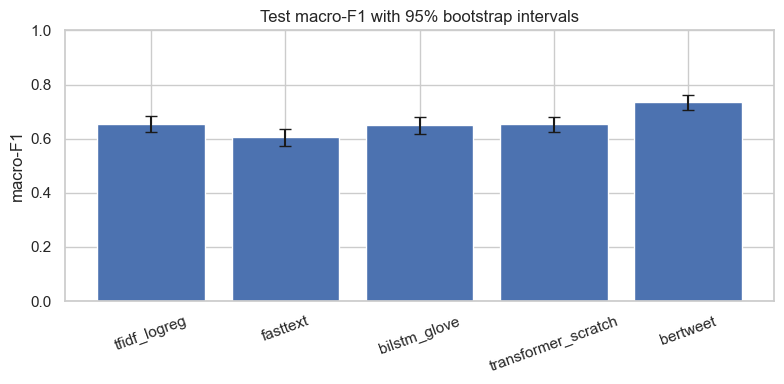

In [3]:
boot_rows = []
for name in MODEL_NAMES:
    print("bootstrapping", name)
    b = bootstrap_metrics(frames[name], n_boot=2000, seed=42)
    boot_rows.append(dict(model=name, **b))
final_tbl = pd.DataFrame(boot_rows)
cols = ["model",
        "macro_f1_point", "macro_f1_mean", "macro_f1_lo", "macro_f1_hi",
        "rmse_point", "rmse_mean", "rmse_lo", "rmse_hi",
        "accuracy_point", "accuracy_mean", "accuracy_lo", "accuracy_hi",
        "f1_negative_point", "f1_negative_mean", "f1_negative_lo", "f1_negative_hi",
        "f1_neutral_point", "f1_neutral_mean", "f1_neutral_lo", "f1_neutral_hi",
        "f1_positive_point", "f1_positive_mean", "f1_positive_lo", "f1_positive_hi"]
final_tbl = final_tbl[cols]
display(final_tbl.round(4))
final_tbl.round(4).to_csv("reports/final_table.csv", index=False)
final_table_to_tex(final_tbl, "reports/final_table.tex")
print("Wrote reports/final_table.csv and reports/final_table.tex")
plot_macro_f1_ci(final_tbl, FIG + "final_macro_f1.png")


*Interpretation:* BERTweet has the highest point macro-F1 (0.7368) and the highest bootstrap mean (0.7359), with a 95 percent interval of [0.7074, 0.7629]. The next cluster is TF-IDF LogReg, transformer-from-scratch, and BiLSTM-GloVe, all near 0.65 with intervals that overlap each other. fastText is lowest at 0.6048 ([0.5745, 0.6360]). BERTweet also has the lowest RMSE (0.5567) and the highest accuracy (0.7908). The negative-class F1 gap is large: BERTweet 0.5811 versus 0.33-0.46 for the others.


## Paired bootstrap: BERTweet against each other model
On each resample, macro-F1(bertweet) - macro-F1(other) is computed. The table reports the mean difference, the 95 percent interval, and the share of resamples where the difference is at or below zero.


In [4]:
paired_rows = []
for name in MODEL_NAMES:
    if name == "bertweet":
        continue
    d = paired_bootstrap_f1_diff(frames["bertweet"], frames[name], n_boot=2000, seed=42)
    paired_rows.append(dict(compare=f"bertweet - {name}", **d))
paired = pd.DataFrame(paired_rows)
display(paired.round(4))
print("lower ends of the intervals:", paired["lo"].round(4).tolist())
print("mean diffs:", paired["mean_diff"].round(4).tolist())

# validation seed std of final BERTweet config (E3) from experiment_log
import json as _json
_log = pd.read_csv("reports/experiment_log.csv")
_e3 = _log[_log["model"] == "bertweet"]
_e3 = _e3[_e3["params"].apply(lambda p: _json.loads(p).get("exp") == "E3")]
print("E3 BERTweet val macro-F1 over seeds:", _e3["val_macro_f1"].tolist())
print("E3 val macro-F1 std:", round(float(_e3["val_macro_f1"].std(ddof=1)), 4))


,compare,mean_diff,lo,hi,share_le_0
0,bertweet - tfidf_logreg,0.0817,0.0507,0.1131,0.0
1,bertweet - fasttext,0.1316,0.0977,0.1646,0.0
2,bertweet - bilstm_glove,0.0864,0.0548,0.1174,0.0
3,bertweet - transformer_scratch,0.0820,0.0498,0.1144,0.0


lower ends of the intervals: [0.0507, 0.0977, 0.0548, 0.0498]
mean diffs: [0.0817, 0.1316, 0.0864, 0.082]
E3 BERTweet val macro-F1 over seeds: [0.7432, 0.7359, 0.7376]
E3 val macro-F1 std: 0.0038


*Interpretation:* on every paired bootstrap, BERTweet's macro-F1 minus the other model is positive. Mean gaps are about +0.08 to +0.09 against TF-IDF LogReg, BiLSTM, and the scratch transformer (0.0817, 0.0864, 0.0820), and +0.13 against fastText (0.1316). None of the 2000 resamples yielded a non-positive difference (share_le_0 = 0.0 for all four pairs), and the lower ends of the intervals are about 0.05 or higher (0.0507, 0.0977, 0.0548, 0.0498). The bootstrap resamples test tweets only and each model has one training run for the test result, so training variation is not included (the validation std over seeds of the final BERTweet configuration is about 0.004).


## Paired bootstrap among the four older models
The same paired bootstrap is run for all six pairs among TF-IDF LogReg, fastText, BiLSTM and the from-scratch Transformer.


In [5]:
older = [m for m in MODEL_NAMES if m != "bertweet"]
older_rows = []
for a, b in combinations(older, 2):
    d = paired_bootstrap_f1_diff(frames[a], frames[b], n_boot=2000, seed=42)
    older_rows.append(dict(compare=f"{a} - {b}", model_a=a, model_b=b, **d))
older_paired = pd.DataFrame(older_rows)
display(older_paired.round(4))

# which pairs involving fastText exclude 0?
ft_pairs = older_paired[older_paired["compare"].str.contains("fasttext")]
print("fastText pairs where the 95% interval excludes 0:")
for _, r in ft_pairs.iterrows():
    excludes = (r["lo"] > 0) or (r["hi"] < 0)
    print(f"  {r['compare']}: mean_diff={r['mean_diff']:.4f}, "
          f"[{r['lo']:.4f}, {r['hi']:.4f}], excludes_0={bool(excludes)}")


,compare,model_a,model_b,mean_diff,lo,hi,share_le_0
0,tfidf_logreg - fasttext,tfidf_logreg,fasttext,0.0499,0.0206,0.0789,0.0000
1,tfidf_logreg - bilstm_glove,tfidf_logreg,bilstm_glove,0.0047,-0.0228,0.0305,0.3505
2,tfidf_logreg - transformer_scratch,tfidf_logreg,transformer_scratch,0.0003,-0.0281,0.0275,0.4920
3,fasttext - bilstm_glove,fasttext,bilstm_glove,-0.0452,-0.0738,-0.0140,0.9990
4,fasttext - transformer_scratch,fasttext,transformer_scratch,-0.0496,-0.0830,-0.0164,0.9970
5,bilstm_glove - transformer_scratch,bilstm_glove,transformer_scratch,-0.0044,-0.0310,0.0218,0.6185


fastText pairs where the 95% interval excludes 0:
  tfidf_logreg - fasttext: mean_diff=0.0499, [0.0206, 0.0789], excludes_0=True
  fasttext - bilstm_glove: mean_diff=-0.0452, [-0.0738, -0.0140], excludes_0=True
  fasttext - transformer_scratch: mean_diff=-0.0496, [-0.0830, -0.0164], excludes_0=True


*Interpretation:* among the four older models, the paired intervals that exclude 0 are the three pairs with fastText: LogReg minus fastText is positive ([0.0206, 0.0789]), and fastText minus BiLSTM or the scratch transformer is negative (intervals end below 0). So fastText is lower than each of those three on this test set. The pairs among LogReg, BiLSTM and the scratch transformer all have intervals that include 0, so those differences overlap and this bootstrap does not separate them.


## Confusion matrices and learning curves


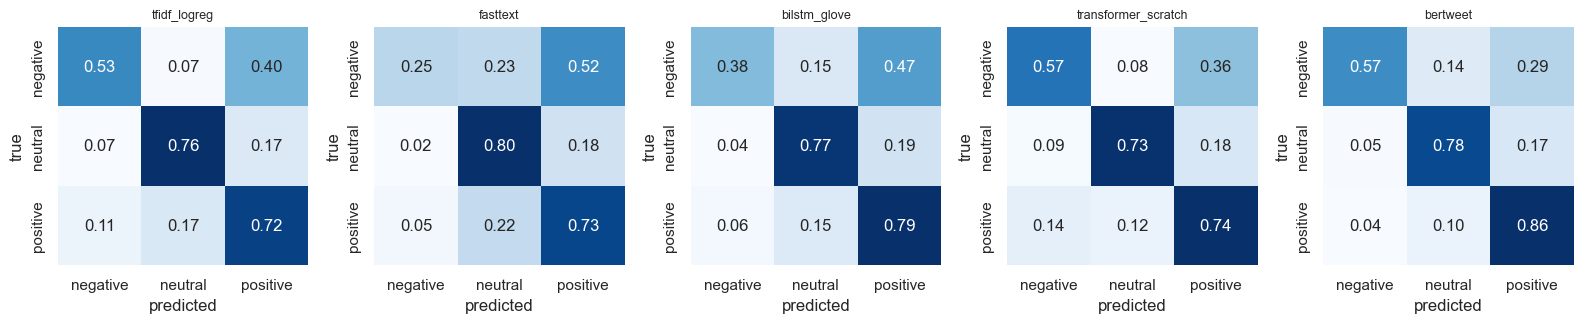

True-negative off-diagonal rates (row-normalised):


,model,n_negative,neg_to_neu,neg_to_pos
0,tfidf_logreg,152,0.0724,0.4013
1,fasttext,152,0.2303,0.5197
2,bilstm_glove,152,0.1513,0.4737
3,transformer_scratch,152,0.0789,0.3553
4,bertweet,152,0.1447,0.2895


BERTweet neg->neu: 0.1447
LogReg neg->neu: 0.0724
Transformer neg->neu: 0.0789
fastText neg->neu: 0.2303
BiLSTM neg->neu: 0.1513
BERTweet neg->pos: 0.2895
other neg->pos range: 0.3553 to 0.5197


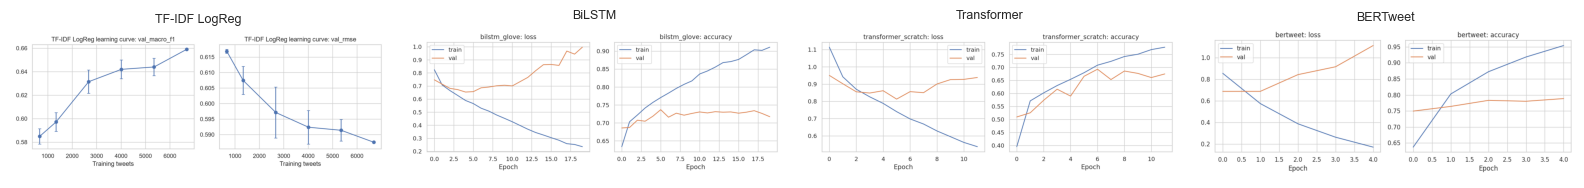

All four learning-curve images were found.
History notes from notebooks 03, 04 and 06 (seed-42 final runs):
  BiLSTM: best validation macro-F1 at epoch 15; train loss kept falling while val loss rose after the mid epochs.
  Transformer: best validation macro-F1 at epoch 7.
  BERTweet: ran all 5 epochs; best validation macro-F1 was at epoch 5 (the last epoch), so this run was not cut short by early stopping.
  TF-IDF panel is over training-set size; the neural panels are over epochs.


In [6]:
plot_confusion_grid(frames, FIG + "final_confusion_grid.png")

neg_rates = negative_confusion_rates(frames)
print("True-negative off-diagonal rates (row-normalised):")
display(neg_rates.round(4))
print("BERTweet neg->neu:", round(float(neg_rates.loc[neg_rates.model=="bertweet","neg_to_neu"].iloc[0]), 4))
print("LogReg neg->neu:", round(float(neg_rates.loc[neg_rates.model=="tfidf_logreg","neg_to_neu"].iloc[0]), 4))
print("Transformer neg->neu:", round(float(neg_rates.loc[neg_rates.model=="transformer_scratch","neg_to_neu"].iloc[0]), 4))
print("fastText neg->neu:", round(float(neg_rates.loc[neg_rates.model=="fasttext","neg_to_neu"].iloc[0]), 4))
print("BiLSTM neg->neu:", round(float(neg_rates.loc[neg_rates.model=="bilstm_glove","neg_to_neu"].iloc[0]), 4))
print("BERTweet neg->pos:", round(float(neg_rates.loc[neg_rates.model=="bertweet","neg_to_pos"].iloc[0]), 4))
print("other neg->pos range:",
      round(float(neg_rates.loc[neg_rates.model!="bertweet","neg_to_pos"].min()), 4), "to",
      round(float(neg_rates.loc[neg_rates.model!="bertweet","neg_to_pos"].max()), 4))

curve_paths = {
    "TF-IDF LogReg": FIG + "b5_learning_curve_logreg.png",
    "BiLSTM": FIG + "curves_bilstm_glove.png",
    "Transformer": FIG + "curves_transformer_scratch.png",
    "BERTweet": FIG + "curves_bertweet.png",
}
missing = plot_learning_curve_panel(curve_paths, FIG + "final_learning_curves.png")
if missing:
    print("Missing learning-curve images (skipped):", missing)
else:
    print("All four learning-curve images were found.")
print("History notes from notebooks 03, 04 and 06 (seed-42 final runs):")
print("  BiLSTM: best validation macro-F1 at epoch 15; train loss kept falling while val loss rose after the mid epochs.")
print("  Transformer: best validation macro-F1 at epoch 7.")
print("  BERTweet: ran all 5 epochs; best validation macro-F1 was at epoch 5 (the last epoch), so this run was not cut short by early stopping.")
print("  TF-IDF panel is over training-set size; the neural panels are over epochs.")


*Interpretation:* the confusion grid shows that every model is strongest on neutral and weakest on negative. The printed negative-class rates show that BERTweet's negative-to-neutral rate (0.1447) is not lower than LogReg (0.0724) or the transformer (0.0789); it is lower than fastText (0.2303) and about equal to the BiLSTM (0.1513). Its clear gain is negative-to-positive (0.2895 against 0.3553 to 0.5197 for the others). The learning-curve panel uses four saved figures: the TF-IDF panel is over training-set size, while the BiLSTM, Transformer and BERTweet panels are over epochs. From the seed-42 history tables, the BiLSTM's best validation macro-F1 was at epoch 15, with train loss still falling while validation loss rose later; the Transformer's best was at epoch 7; BERTweet ran all 5 epochs and its best validation macro-F1 was at epoch 5, so that run was not cut short by early stopping. Macro-F1 point estimates with bootstrap intervals are in final_macro_f1.png.


## Short discussion

BERTweet is the best of the five models on this shared test split: highest macro-F1, accuracy, and per-class F1, and lowest RMSE. The gain is clearest on the negative class, which every from-scratch model struggled with. Classical TF-IDF LogReg remains competitive with the BiLSTM and the scratch transformer on macro-F1. The gap to BERTweet possibly comes from pretraining on tweets, which these results do not test; a direct test would be to fine-tune the same architecture from random initialisation on this dataset.

Error analysis (notebook 08) shows that most tweets are easy for all models, while a shared hard set of 128 tweets remains wrong everywhere. Performance falls when annotator agreement falls, and BERTweet keeps the lead in the high-agreement and mid-agreement bins. Heuristic slices (negation, news-style, sarcasm cues) do not reverse the ranking.

Limits: one test split, heuristic slices, one training run per model for the test predictions (so training variation is not in the bootstrap), and BERTweet uses more compute and a pretrained checkpoint.
